In [1]:
import numpy as np
from classy import Class

In [2]:
# Polynomial for A parameter
def A(x):
    # Coefficients for A(x) (from highest degree to constant term)
    coeff_A = [-7.369e-06, -6.597e-05, -0.0001348, 0.0004274, 0.001855, 
               5.068e-05, -0.007855, -0.006923, 0.01576, 0.02598, -0.01983, -0.08118, 0.9416]
    return np.polyval(coeff_A, x)

# Polynomial for b parameter
def b(x):
    # Coefficients for b(x) (from highest degree to constant term)
    coeff_b = [-0.0001591, -0.0005741, 0.002432, 0.01034, -0.01059, 
               -0.06682, 0.007572, 0.2287, 0.07249, -0.7259, 0.6496, 0.5267]
    return np.polyval(coeff_b, x)

# Polynomial for mu parameter
def mu(x):
    # Coefficients for mu(x) (from highest degree to constant term)
    coeff_mu = [-4.667e-05, 0.0006367, 0.002832, -0.003391, -0.01729, 
                -0.006905, 0.04416, 0.01063, 0.1161, -0.2879, 0.1581, -0.1738, 0.576]
    return np.polyval(coeff_mu, x)

In [3]:
# Example usage
m_a = 0.19
log_m_a = np.log(m_a)
print(f"A(log({m_a})) = {A(log_m_a)}")
print(f"b(log({m_a})) = {b(log_m_a)}")
print(f"mu(log({m_a})) = {mu(log_m_a)}")

A(log(0.19)) = 1.002499612617456
b(log(0.19)) = -1.959930435713995
mu(log(0.19)) = 4.1233281729556595


CLASS computation finished successfully.
dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_ncdm[0]', '(.)p_ncdm[0]', '(.)rho_ncdm[1]', '(.)p_ncdm[1]', '(.)rho_lambda', '(.)rho_crit', '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])
N_eff = 3.425426146703591


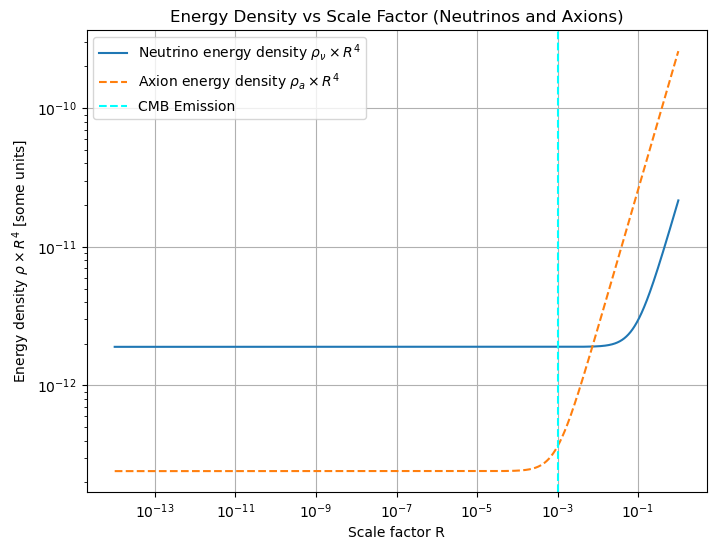

In [4]:
# Define the cosmological parameters for LambdaCDM + neutrinos + axions
params = {
    'output': 'mPk',  # Output: matter power spectrum
    'P_k_max_1/Mpc': 3.0,  # Maximum wavenumber for the power spectrum
    'h': 0.67556,          # Reduced Hubble parameter
    'omega_b': 0.022032,   # Baryon density
    'omega_cdm': 0.12038,  # Cold dark matter density
    'n_s': 0.9619,         # Spectral index
    'A_s': 2.215e-9,       # Amplitude of scalar perturbations
    'tau_reio': 0.0925,    # Optical depth to reionization

    # Neutrino related parameters
    'N_ur': 0.0,
    'N_ncdm': '2',       # Only one class of massive neutrinos
    'deg_ncdm': '3, 1',         # 3 degenerate neutrinos
    'T_ncdm': '0.71611, 0.68481',  # Decoupling temperatures for neutrinos and axions, 0.71611, 0.68481
    'm_ncdm': f'{0.006}, {0.57}',
    'ncdm_psd_parameters': f'{A(np.log(0.57))},{b(np.log(0.57))},{mu(np.log(0.57))}',  # Axion distribution function params

    'perturbed_recombination': 'yes',
    'use_ncdm_psd_files': '0, 0',
    'ncdm_quadrature_strategy': '0, 0',
    # 'ncdm_psd_filenames': '/home/krzysztof/Workspace/class_3.2.3/psd_FD_single.dat',

    # 'tensor_method': 'massless',



    # Verbosity settings
    'background_verbose': 1,
    'input_verbose': 1,
    'perturbations_verbose': 1,
    'output_verbose': 1,
    'thermodynamics_verbose': 1
}

# Create a CLASS instance
cosmo = Class()

# Set the parameters and run CLASS
cosmo.set(params)
cosmo.compute()
print("CLASS computation finished successfully.")  # Log if successful

# --- Retrieve the background quantities --------------------------------
background = cosmo.get_background()
# Print all keys available in the background dictionary
print(background.keys())

# --- Retrieve the derived parameters (pass the list of parameters you want) --------------------------------
derived_params = cosmo.get_current_derived_parameters(['Neff'])  # Corrected method with argument

# Extract Neff (effective number of relativistic species)
Neff = derived_params['Neff']
print(f"N_eff = {Neff}")


# --- Example: Extract the scale factor and energy density of neutrinos and axions --------------------------------
z = background['z']
R = 1 / (1 + z)
rho_nu = background['(.)rho_ncdm[0]']  # Neutrino energy density (ncdm species 1)
rho_axion = background['(.)rho_ncdm[1]']  # Axion energy density (ncdm species 2)

# Multiply by R^4 for both species and plot the result
rho_nu_R4 = rho_nu * R**4
rho_axion_R4 = rho_axion * R**4

# Plotting the result
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(R, rho_nu_R4, label=r'Neutrino energy density $\rho_\nu \times R^4$')
plt.plot(R, rho_axion_R4, label=r'Axion energy density $\rho_a \times R^4$', linestyle='--')

# Finalize the plot
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Scale factor R')
plt.ylabel(r'Energy density $\rho \times R^4$ [some units]')
plt.title('Energy Density vs Scale Factor (Neutrinos and Axions)')
plt.axvline(1e-3, color='cyan', linestyle='--', label='CMB Emission')
plt.legend()
plt.grid(True)
plt.show()